# Data preprocessing

## Setup

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

import seaborn as sns

from scripts.utils import build_dataframe_from_txts

## Read data

In [2]:
# Example usage:
data_dir = '/home/ids/nnavarro-24/data/emidec-dataset-1.0.1'
df_train = build_dataframe_from_txts(os.path.join(data_dir, 'training'))
df_test = build_dataframe_from_txts(os.path.join(data_dir, 'testing'))

# concat df_train and df_test
df = pd.concat([df_train, df_test], ignore_index=True)

## Preprocessing

In [3]:
df = df.copy()

# Remove Gap_between_slices column
df.drop(columns=['Gap_between_slices'], inplace=True)

# Encode binary categorical features
binary_cols = ['Sex', 'Overweight', 'Arterial_hypertension', 'Diabetes', 
               'Familial_history_of_coronary_artery_disease', 'ECG_(ST_+)']
for col in binary_cols:
    df[col] = df[col].map({'N': 0, 'Y': 1, 'F': 0, 'M': 1})

# Convert numeric columns
numeric_cols = ['Age', 'Tobacco', 'Troponin', 'Killip_Max', 'FEVG', 'NTProBNP']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Encode label
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])  # normal = 0, pathological = 1

In [4]:
X = df.drop('label', axis=1)
y = df['label']

### EDA

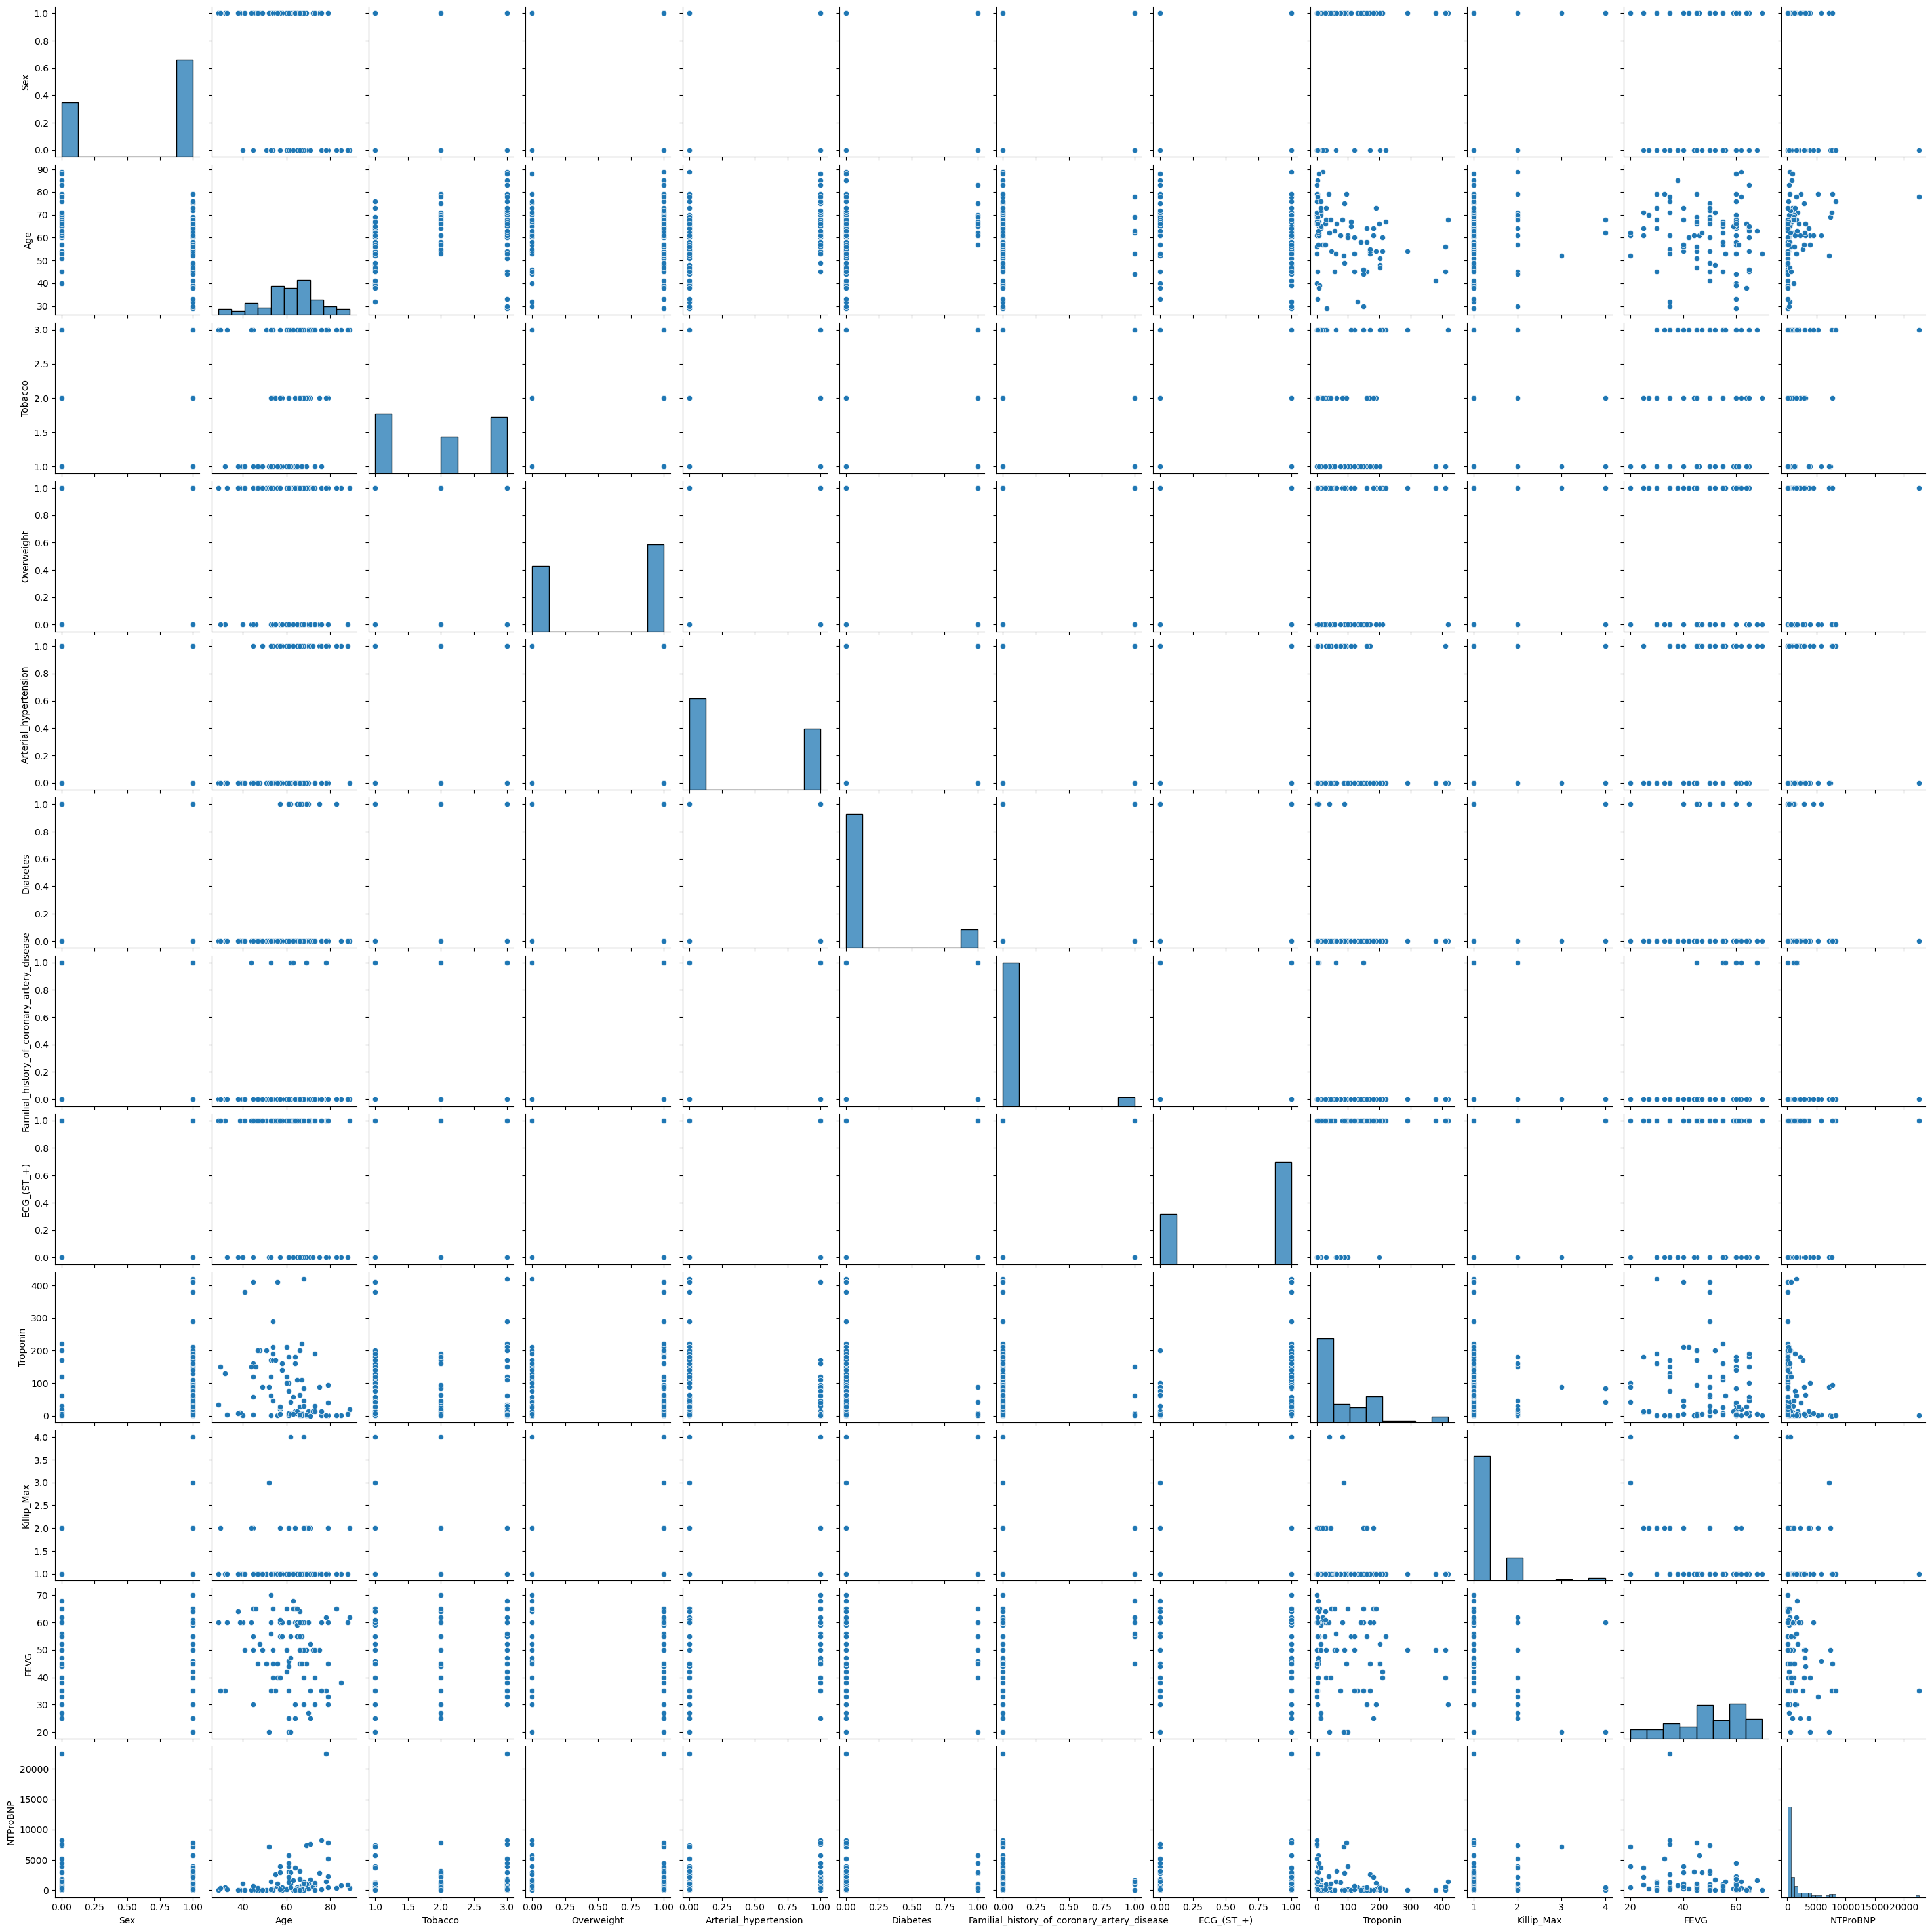

In [5]:
sns.pairplot(X)

### Scaling and transformations

In [6]:
from sklearn.preprocessing import StandardScaler

for col in ['NTProBNP', 'Troponin']:
    X[col] = X[col].astype(float)
    X[col] = X[col].apply(lambda x: np.log1p(x))  # log1p handles zero

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Modeling

### Feature selection model

SVM with a linear kernel and a hinge loss [6] as an initial feature selection step. Designed to remove redundant
features at the first step and provide robust features for final classification in
the second step.

In [7]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

linear_svm = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=10000, class_weight='balanced')
linear_svm.fit(X, y)

# Select important features
selector = SelectFromModel(linear_svm, prefit=True)
X_selected = selector.transform(X_scaled)

#### Relevant features

In [8]:
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print("Selected features:", list(selected_features))

Selected features: ['Age', 'Troponin', 'FEVG']


### Prediction model

SVM with a radial basis function kernel to refine the separation boundary between the two classes

#### Grid search

In [9]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=5)
grid.fit(X_selected, y)
print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.86
Best params: {'C': 10, 'gamma': 0.01}


#### Cross-validation

In [10]:
rbf_svm = SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced')
scores = cross_val_score(rbf_svm, X_selected, y, cv=5)
print("Cross-val accuracy:", scores.mean())

Cross-val accuracy: 0.86
